In [96]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("hongweicao/catanddogsmall")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\morga\.cache\kagglehub\datasets\hongweicao\catanddogsmall\versions\1


In [97]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16, ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

In [98]:
trainPath = path + "/dogvscat_small/train"
testPath = path + "/dogvscat_small/test"
valPath = path + "/dogvscat_small/validation"

In [99]:
dataGenTrain = ImageDataGenerator(
    rescale = 1/255,
    rotation_range = 20,
    width_shift_range = 0.2,
    height_shift_range = 0.2,
    zoom_range = 0.2,
    shear_range = 0.2,
    horizontal_flip = True
)

dataGenTest = ImageDataGenerator( rescale = 1/255 )

In [100]:
trainGen = dataGenTrain.flow_from_directory(trainPath,target_size=(224,224),batch_size=32,class_mode="binary")
testGen = dataGenTest.flow_from_directory(testPath,target_size=(224,224),batch_size=32,class_mode="binary")
valGen = dataGenTest.flow_from_directory(valPath,target_size=(224,224),batch_size=32,class_mode="binary")

Found 2000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


In [101]:
'''baseModel = VGG16(weights="imagenet",include_top=False,input_shape=(224,224,3))
for layer in baseModel.layers:
    layer.trainable = False

x = baseModel.output
x = Flatten()(x)
x = Dense(128,activation="relu")(x)
x = Dropout(0.5)(x)
predictions = Dense(1,activation="sigmoid")(x)'''

'baseModel = VGG16(weights="imagenet",include_top=False,input_shape=(224,224,3))\nfor layer in baseModel.layers:\n    layer.trainable = False\n\nx = baseModel.output\nx = Flatten()(x)\nx = Dense(128,activation="relu")(x)\nx = Dropout(0.5)(x)\npredictions = Dense(1,activation="sigmoid")(x)'

In [102]:
baseModel = VGG16(weights="imagenet",include_top=False,input_shape=(224,224,3))
for i in range(0,len(baseModel.layers)-4):
    baseModel.layers[i].trainable = False

for i in range(0,4):
    # Unfreeze last 4 layers
    baseModel.layers[-(i+1)].trainable = True

x = baseModel.output
x = Flatten()(x)
x = Dense(128,activation="relu")(x)
x = Dropout(0.5)(x)
predictions = Dense(1,activation="sigmoid")(x)

In [103]:
'''baseModel = ResNet50(weights="imagenet",include_top=False,input_shape=(224,224,3))
for i in range(0,len(baseModel.layers)-4):
    baseModel.layers[i].trainable = False

for i in range(0,4):
    # Unfreeze last 4 layers
    baseModel.layers[-(i+1)].trainable = True

x = baseModel.output
x = Flatten()(x)
x = Dense(128,activation="relu")(x)
x = Dropout(0.5)(x)
predictions = Dense(1,activation="sigmoid")(x)'''

'baseModel = ResNet50(weights="imagenet",include_top=False,input_shape=(224,224,3))\nfor i in range(0,len(baseModel.layers)-4):\n    baseModel.layers[i].trainable = False\n\nfor i in range(0,4):\n    # Unfreeze last 4 layers\n    baseModel.layers[-(i+1)].trainable = True\n\nx = baseModel.output\nx = Flatten()(x)\nx = Dense(128,activation="relu")(x)\nx = Dropout(0.5)(x)\npredictions = Dense(1,activation="sigmoid")(x)'

In [104]:
'''baseModel = ResNet50(weights="imagenet",include_top=False,input_shape=(224,224,3))
for layer in baseModel.layers:
    layer.trainable = False

x = baseModel.output
x = Flatten()(x)
x = Dense(128,activation="relu")(x)
x = Dropout(0.5)(x)
predictions = Dense(1,activation="sigmoid")(x)'''

'baseModel = ResNet50(weights="imagenet",include_top=False,input_shape=(224,224,3))\nfor layer in baseModel.layers:\n    layer.trainable = False\n\nx = baseModel.output\nx = Flatten()(x)\nx = Dense(128,activation="relu")(x)\nx = Dropout(0.5)(x)\npredictions = Dense(1,activation="sigmoid")(x)'

In [105]:
model = Model(inputs=baseModel.input,outputs=predictions)
model.compile(Adam(learning_rate=1e-5),loss="binary_crossentropy",metrics=["accuracy"])
fittedM = model.fit(trainGen,epochs=5,validation_data=testGen)

Epoch 1/5
63/63 [==============================] - 195s 3s/step - loss: 0.6452 - accuracy: 0.6290 - val_loss: 0.4547 - val_accuracy: 0.8220
Epoch 2/5
63/63 [==============================] - 191s 3s/step - loss: 0.4512 - accuracy: 0.7975 - val_loss: 0.2677 - val_accuracy: 0.8870
Epoch 3/5
63/63 [==============================] - 182s 3s/step - loss: 0.3173 - accuracy: 0.8630 - val_loss: 0.1959 - val_accuracy: 0.9220
Epoch 4/5
63/63 [==============================] - 188s 3s/step - loss: 0.2620 - accuracy: 0.8920 - val_loss: 0.1669 - val_accuracy: 0.9330
Epoch 5/5
63/63 [==============================] - 185s 3s/step - loss: 0.2247 - accuracy: 0.9125 - val_loss: 0.1538 - val_accuracy: 0.9400


In [106]:
loss, accuracy = model.evaluate(testGen)
print(loss)
print(accuracy)

32/32 [==============================] - 51s 2s/step - loss: 0.1538 - accuracy: 0.9400
0.15375642478466034
0.9399999976158142


In [107]:
imagePath = path +"\dogvscat_small\\validation\cats\\1016.jpg"
img = image.load_img(imagePath,target_size=(224,224))
img = image.img_to_array(img)
newImg = np.expand_dims(img,axis=0)
newImg = newImg/255
prediction = model.predict(newImg)
prediction = "cat" if prediction[0] < 0.5 else "dog"
print(prediction)

1/1 [==============================] - 0s 222ms/step
cat


In [108]:
images,labels = next(valGen)
batchPred = model.predict(images)
print(batchPred)

1/1 [==============================] - 2s 2s/step
[[7.3982269e-01]
 [1.3217755e-03]
 [9.9773270e-01]
 [5.5733627e-01]
 [1.8235430e-01]
 [1.3346181e-03]
 [5.7823385e-05]
 [3.8012940e-02]
 [1.9464090e-02]
 [9.1294819e-01]
 [9.4963568e-01]
 [9.3018222e-01]
 [9.9993229e-01]
 [9.6102756e-01]
 [2.2831315e-01]
 [9.9978405e-01]
 [1.5037890e-02]
 [9.9822277e-01]
 [1.6319652e-01]
 [9.7532302e-01]
 [1.4633386e-03]
 [3.9942807e-01]
 [9.8613518e-01]
 [2.0255566e-02]
 [2.0651518e-01]
 [9.9222201e-01]
 [2.2106463e-02]
 [9.8686039e-01]
 [8.2626650e-03]
 [9.3933815e-01]
 [3.6226037e-01]
 [2.5400499e-02]]


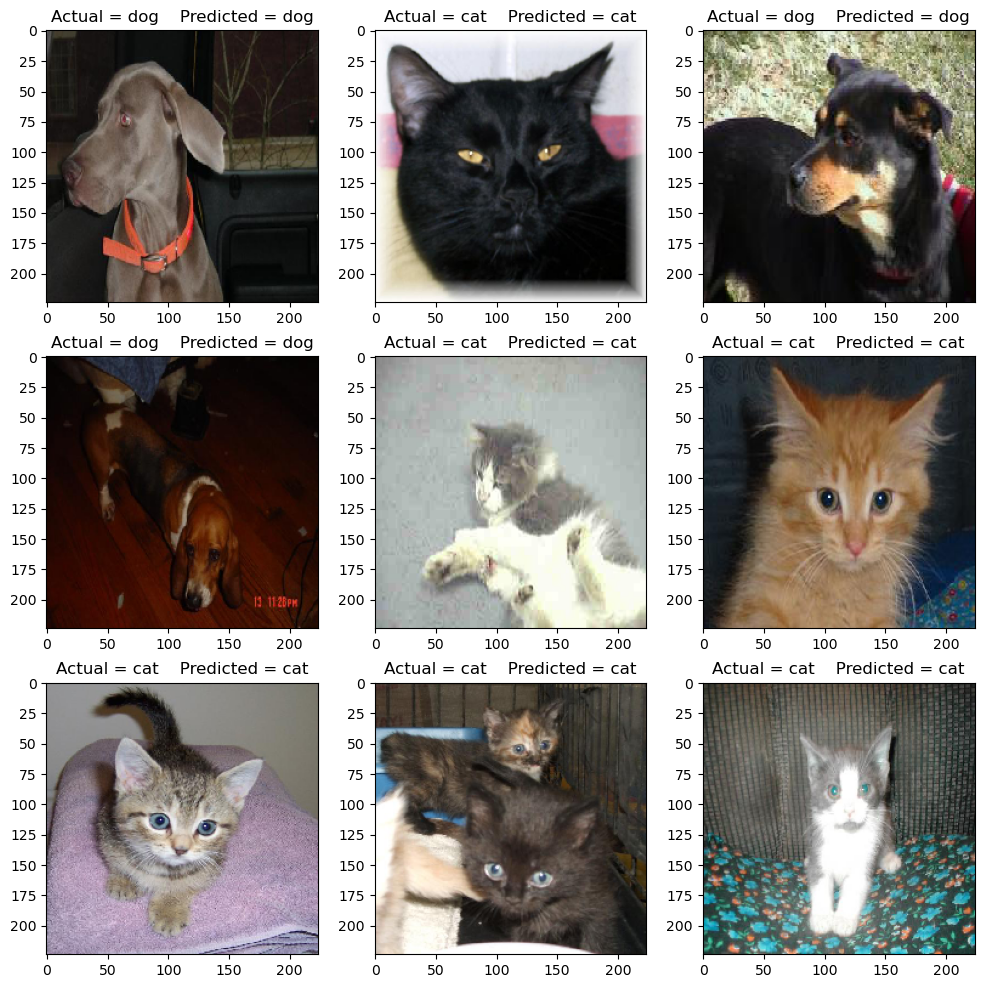

In [109]:
plt.figure(figsize=(12,12))
for i in range(0,9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    actualLabel = "cat" if labels[i] == 0 else "dog"
    predLabel = "cat" if batchPred[i] < 0.5 else "dog"
    plt.title(f"Actual = {actualLabel}    Predicted = {predLabel}")

plt.show()

In [110]:
'''
VGG16:
Unfrozen - 
loss - 0.1520911008119583
accuracy - 0.9340000152587891

frozen- 
loss - 0.3609403371810913
accuracy - 0.8640000224113464


ResNet50:
Unfrozen - 
loss - 0.6531376838684082
accuracy - 0.6190000176429749

frozen - 
loss - 0.6663942933082581
accuracy - 0.6019999980926514
'''

'\nVGG16:\nUnfrozen - \nloss - 0.1520911008119583\naccuracy - 0.9340000152587891\n\nfrozen- \nloss - 0.3609403371810913\naccuracy - 0.8640000224113464\n\n\nResNet50:\nUnfrozen - \nloss - 0.6531376838684082\naccuracy - 0.6190000176429749\n\nfrozen - \nloss - 0.6663942933082581\naccuracy - 0.6019999980926514\n'